## **CHARTING A COURSE FOR MWANGAZA FILM STUDIO**

### **PROJECT OBJECTIVES**
Help Mwangaza studio determine what kinds of movies are most successful at the box office, using available data.

### **DATA**
In the zippedData folder, movie datasets were sourced from Box Office Mojo, IMDb, Rotten Tomatoes, The Movie Database (TMDb), and The Numbers. Specifically, the files used were:

tn.movie_budgets.csv:used for production budgets and release dates.

bom.movie_gross.csv.gz: provided domestic and worldwide gross earnings.

im.db.zip (from IMDb): included the movie_basics and movie_ratings tables for IMDb ratings.

### **RESEARCH OBJECTIVES**
- **Determine Market Viability – Assess which types of films resonate most with audiences and what factors contribute to commercial success.**

- **Guide Strategic Decision-Making – Provide recommendations on which genres, styles, or storytelling approaches the new company should pursue.**

- **To determine the optimal range of movie runtime that is most often associated with high box office success and use it to give insights on the length of an ideal movie.**

### LIBRARIES

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import numpy as np

### **DATA UNDERSTANDING AND DATA CLEANING**

#### **Understanding bom.movie_gross file**

In [2]:
#Loading the first dataset
df = pd.read_csv("bom.movie_gross.csv.gz")
df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [4]:
df.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


#### **Data cleaning bom.movie_gross file**

In [5]:
#looking for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

foreign_gross     1350
domestic_gross      28
studio               5
title                0
year                 0
dtype: int64

In [6]:
df.dropna(subset=["domestic_gross","foreign_gross"],inplace=True)

In [7]:
# Looking for missing values after cleaning
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

studio            2
title             0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64

In [8]:
df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3275,I Still See You,LGF,1400.0,1500000,2018
3286,The Catcher Was a Spy,IFC,725000.0,229000,2018
3309,Time Freak,Grindstone,10000.0,256000,2018
3342,Reign of Judges: Title of Liberty - Concept Short,Darin Southa,93200.0,5200,2018


In [9]:
# changing the foreign gross column from strings to int and creating a new column with total gross
df["foreign_gross"] = pd.to_numeric(df["foreign_gross"], errors="coerce")
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']
df

,title,studio,domestic_gross,foreign_gross,year,total_gross
0,Toy Story 3,BV,415000000.0,652000000.0,2010,1.067000e+09
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010,1.025500e+09
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010,9.603000e+08
3,Inception,WB,292600000.0,535700000.0,2010,8.283000e+08
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,7.526000e+08
...,...,...,...,...,...,...
3275,I Still See You,LGF,1400.0,1500000.0,2018,1.501400e+06
3286,The Catcher Was a Spy,IFC,725000.0,229000.0,2018,9.540000e+05
3309,Time Freak,Grindstone,10000.0,256000.0,2018,2.660000e+05
3342,Reign of Judges: Title of Liberty - Concept Short,Darin Southa,93200.0,5200.0,2018,9.840000e+04


#### **Understanding im.db database**

In [10]:
#Loading the second dataset
conn = sqlite3.connect("im.db")
cur = conn.cursor()
cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table'""")
table_names = cur.fetchall()
table_names

[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

In [11]:
sql_df = pd.read_sql("""SELECT * FROM movie_basics;""",conn).head(15)
sql_df

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
5,tt0111414,A Thin Life,A Thin Life,2018,75.0,Comedy
6,tt0112502,Bigfoot,Bigfoot,2017,NaN,"Horror,Thriller"
7,tt0137204,Joe Finds Grace,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy"
8,tt0139613,O Silêncio,O Silêncio,2012,NaN,"Documentary,History"
9,tt0144449,Nema aviona za Zagreb,Nema aviona za Zagreb,2012,82.0,Biography


#### **Data Cleaning im.db database**

In [12]:
#Checking for NullValues
missing_null_values = sql_df.isnull().sum()
missing_null_values

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    3
genres             0
dtype: int64

In [13]:
#Replacing null values for runtime with the runtime mode
sql_df["runtime_minutes"] = sql_df["runtime_minutes"].fillna(sql_df["runtime_minutes"].mode()[0])

In [14]:
# Checking if the runtime nullvalues have been replaced
missing_null_values = sql_df.isnull().sum()
missing_null_values

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

In [15]:
# Selecting movie_ratings table for cleaning and visualiztion
movie_ratings = pd.read_sql("""SELECT * FROM movie_ratings;""",conn).head()
movie_ratings

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [16]:
#Checking for null values
missing_null_values = movie_ratings.isnull().sum()
missing_null_values

movie_id         0
averagerating    0
numvotes         0
dtype: int64

In [17]:
# Selecting movie_akas
sql_df = pd.read_sql("""SELECT * FROM movie_akas ;""",conn).head()
sql_df

,movie_id,ordering,title,region,language,types,attributes,is_original_title
0,tt0369610,10,Джурасик свят,BG,bg,None,None,0.0
1,tt0369610,11,Jurashikku warudo,JP,None,imdbDisplay,None,0.0
2,tt0369610,12,Jurassic World: O Mundo dos Dinossauros,BR,None,imdbDisplay,None,0.0
3,tt0369610,13,O Mundo dos Dinossauros,BR,None,None,short title,0.0
4,tt0369610,14,Jurassic World,FR,None,imdbDisplay,None,0.0


In [18]:
#Joining movie_basics and movie_id to get avg_rating,votes,genres,movie_id,primary_title,start_year	and runtime_minutes for visualization
query = """SELECT mr.averagerating AS avg_rating, mr.numvotes AS votes, mb.genres, mb.movie_id, mb.primary_title, mb.start_year, mb.runtime_minutes FROM movie_ratings AS mr JOIN movie_basics as mb ON mr.movie_id = mb.movie_id WHERE mr.numvotes >= 100 ORDER BY avg_rating ASC ;"""

joined = pd.read_sql(query, conn)
joined

,avg_rating,votes,genres,movie_id,primary_title,start_year,runtime_minutes
0,1.0,449,Drama,tt1611056,Hito no sabaku,2010,121.0
1,1.0,125,Comedy,tt1872215,Tunnel Rendez-vous,2011,NaN
2,1.0,520,"Fantasy,Mystery,Romance",tt3855260,Yurameku,2014,61.0
3,1.0,230,Horror,tt6010140,Desu foresuto kyofu no mori 5,2016,65.0
4,1.0,112,"Adventure,Animation,Family",tt4839424,The Autobots,2015,85.0
...,...,...,...,...,...,...,...
28748,9.6,1339,"Adventure,Biography,Documentary",tt4131686,I Want to Live,2015,106.0
28749,9.6,427,Action,tt9760512,D/O Parvathamma,2019,NaN
28750,9.7,5600,"Comedy,Drama",tt7131622,Once Upon a Time ... in Hollywood,2019,159.0
28751,9.7,639,Drama,tt8718580,Eghantham,2018,125.0


In [19]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28753 entries, 0 to 28752
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   avg_rating       28753 non-null  float64
 1   votes            28753 non-null  int64  
 2   genres           28733 non-null  object 
 3   movie_id         28753 non-null  object 
 4   primary_title    28753 non-null  object 
 5   start_year       28753 non-null  int64  
 6   runtime_minutes  27978 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 1.5+ MB


In [20]:
# Merging of the bom.movie_gross and im.db using the years and title 
merged_df = pd.merge(
    df,              # DataFrame 1: box office data
    joined,             # DataFrame 2: IMDb data
    how="inner",         # Only keep matching rows
    left_on=["title", "year"],       # from df
    right_on=["primary_title", "start_year"]  # from imdb_df
)
merged_df

,title,studio,domestic_gross,foreign_gross,year,total_gross,avg_rating,votes,genres,movie_id,primary_title,start_year,runtime_minutes
0,Toy Story 3,BV,415000000.0,652000000.0,2010,1.067000e+09,8.3,682218,"Adventure,Animation,Comedy",tt0435761,Toy Story 3,2010,103.0
1,Inception,WB,292600000.0,535700000.0,2010,8.283000e+08,8.8,1841066,"Action,Adventure,Sci-Fi",tt1375666,Inception,2010,148.0
2,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,7.526000e+08,6.3,167532,"Adventure,Animation,Comedy",tt0892791,Shrek Forever After,2010,93.0
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,2010,6.985000e+08,5.0,211733,"Adventure,Drama,Fantasy",tt1325004,The Twilight Saga: Eclipse,2010,124.0
4,Iron Man 2,Par.,312400000.0,311500000.0,2010,6.239000e+08,7.0,657690,"Action,Adventure,Sci-Fi",tt1228705,Iron Man 2,2010,124.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,The Front Runner,Sony,2000000.0,1200000.0,2018,3.200000e+06,6.2,6372,"Biography,Drama,History",tt7074886,The Front Runner,2018,113.0
1239,Wildlife,IFC,1100000.0,2000000.0,2018,3.100000e+06,6.9,14146,Drama,tt5929754,Wildlife,2018,105.0
1240,I Still See You,LGF,1400.0,1500000.0,2018,1.501400e+06,5.7,5010,"Fantasy,Thriller",tt2160105,I Still See You,2018,98.0
1241,The Catcher Was a Spy,IFC,725000.0,229000.0,2018,9.540000e+05,6.2,4653,"Biography,Drama,War",tt4602066,The Catcher Was a Spy,2018,98.0


#### **Understanding tn.movie_budgets.csv** 

In [21]:
#Loading the third dataset
budget_df = pd.read_csv('tn.movie_budgets.csv')
budget_df 

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


### **Data Cleaning tn.movie_budgets.csv**

In [22]:
budget_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [23]:
# Converting 'release_date' to datetime format
budget_df['release_date'] = pd.to_datetime(budget_df['release_date'])

#Extracting year for merging or comparison
budget_df['release_year'] = budget_df['release_date'].dt.year
# Preview cleaned data
print(budget_df.info())
print(budget_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   object        
 4   domestic_gross     5782 non-null   object        
 5   worldwide_gross    5782 non-null   object        
 6   release_year       5782 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(4)
memory usage: 293.7+ KB
None
   id release_date                                        movie  \
0   1   2009-12-18                                       Avatar   
1   2   2011-05-20  Pirates of the Caribbean: On Stranger Tides   
2   3   2019-06-07                                 Dark Phoenix   
3   4   2015-05-01                      Aveng

In [24]:
budget_df

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_year
0,1,2009-12-18,Avatar,"$425,000,000","$760,507,625","$2,776,345,279",2009
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875",2011
2,3,2019-06-07,Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350",2019
3,4,2015-05-01,Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963",2015
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",2017
...,...,...,...,...,...,...,...
5777,78,2018-12-31,Red 11,"$7,000",$0,$0,2018
5778,79,1999-04-02,Following,"$6,000","$48,482","$240,495",1999
5779,80,2005-07-13,Return to the Land of Wonders,"$5,000","$1,338","$1,338",2005
5780,81,2015-09-29,A Plague So Pleasant,"$1,400",$0,$0,2015


In [41]:
# Removing dollar signs and commas to convert to float
cols_to_clean = ['production_budget', 'worldwide_gross', 'domestic_gross']

for col in cols_to_clean:
    budget_df[col] = budget_df[col].replace(r'[\$,]', '', regex=True).astype(float)

In [26]:
# Calculating  profit for visualization
budget_df['profit'] = budget_df['worldwide_gross'] - budget_df['production_budget']

## **DATA VISUALIZATION**

## **Objective 1**
- **Determine Market Viability – Assess which types of films resonate most with audiences and what factors contribute to commercial success.**

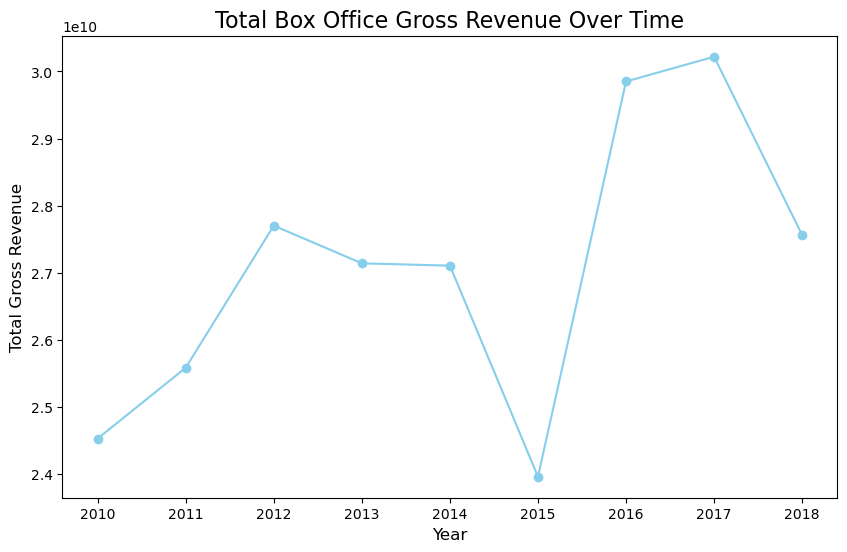

In [45]:
#gross revenue over the years
df["foreign_gross"] = pd.to_numeric(df["foreign_gross"], errors="coerce")
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']
yearly_gross = df.groupby('year')['total_gross'].sum() 
yearly_gross.plot(kind='line', marker='o', figsize=(10, 6), color='skyblue')
plt.title('Total Box Office Gross Revenue Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Gross Revenue', fontsize=12)
plt.xticks(yearly_gross.index.astype(int))
plt.show()

### **From the above line chart:**
- Industry Growth: From the visualization we can see how overall movie earnings have increased or declined from 2010 - 2018.
- Impact of events: Spot drops or spikes due to major events for example in 2015 there was a low attendance brought about by a number of factors for example rise of home entertainment options. From video on demand to Netflix and Hulu.

## **Objective 2**
- **Guide Strategic Decision-Making – Provide recommendations on which genres, styles, or storytelling approaches the new company should pursue.**

In [29]:
# Split genres (some movies have multiple) and calculate median revenue
genre_revenue = (
     merged_df.assign(genres=merged_df['genres'].str.split(','))
    .explode('genres')
    .groupby('genres')['total_gross']
    .median()
    .sort_values(ascending=False)
)

# Show top 10 genres
print("Top 10 Genres by Median Total Gross:")
display(genre_revenue.head(10))

Top 10 Genres by Median Total Gross:


genres
Animation    306900000.0
Sci-Fi       260100000.0
Adventure    240900000.0
Action       133350000.0
Fantasy      114143500.0
Family        96800000.0
Comedy        77600000.0
Mystery       76550000.0
Horror        72950000.0
Thriller      67799999.5
Name: total_gross, dtype: float64

In [30]:
# Split genres (some movies have multiple) and calculate median revenue
genre_revenue = (
     merged_df.assign(genres=merged_df['genres'].str.split(','))
    .explode('genres')
    .groupby('genres')['total_gross']
    .median()
    .sort_values(ascending=False)
)

# Show top 10 genres
print("Top 10 Genres by Median Total Gross:")
display(genre_revenue.head(10))

Top 10 Genres by Median Total Gross:


genres
Animation    306900000.0
Sci-Fi       260100000.0
Adventure    240900000.0
Action       133350000.0
Fantasy      114143500.0
Family        96800000.0
Comedy        77600000.0
Mystery       76550000.0
Horror        72950000.0
Thriller      67799999.5
Name: total_gross, dtype: float64

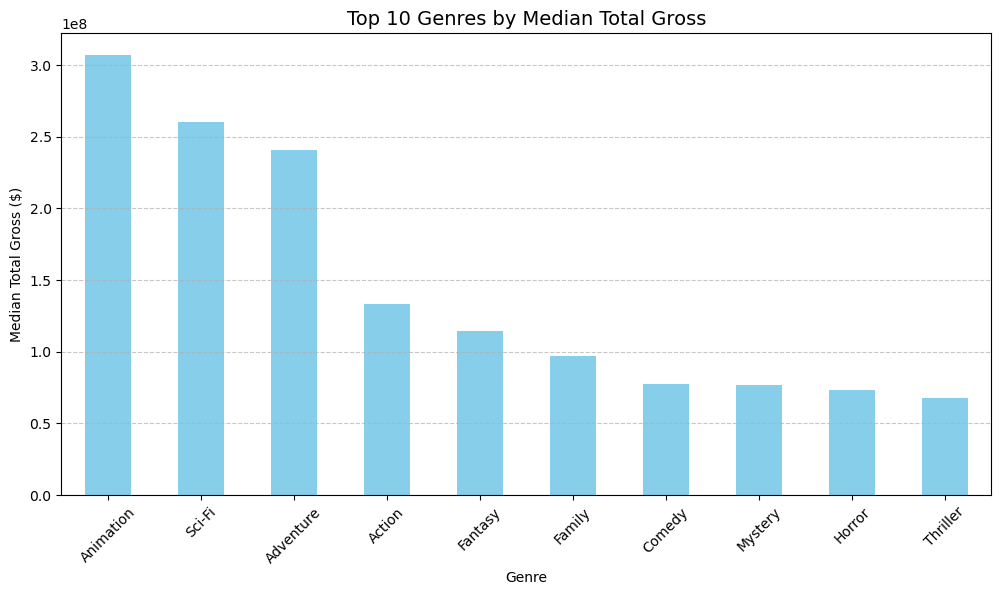

In [31]:
fig = plt.figure(figsize=(12, 6))
genre_revenue.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Genres by Median Total Gross", fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Median Total Gross ($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **From the above bar plot:**
- Animation, Sci-Fi and adventure : These genres consistently perform well, especially with franchises and blockbuster spectacles. Superhero films, epic adventures, and fast-paced action movies tend to attract global audiences.
- Median total gross provides a more balanced view, showing which genres maintain strong earnings across a broader range of films. fer example in our case Animations have a stable financial success
  

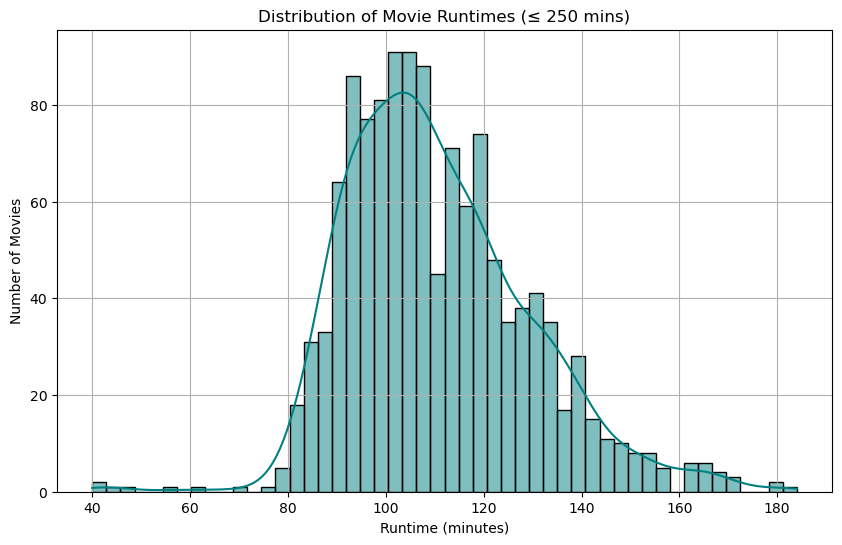

In [33]:
# histogram plot
df_filtered = merged_df[merged_df['runtime_minutes'] <= 250]
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['runtime_minutes'], bins=50, kde=True, color='teal', edgecolor='black')
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Runtimes (≤ 250 mins)")
plt.grid(True)
plt.show()


- Aim for a runtime around 90 - 120 minutes, ensuring tight story telling. i.e A movie that one immerses the audience in its world, making them emotionally invested in the characters and the journey. 

In [35]:
top_runtimes = merged_df['runtime_minutes'].value_counts().head(10).sort_index()
top_runtimes

runtime_minutes
92.0     30
94.0     31
100.0    30
101.0    31
102.0    31
103.0    29
105.0    35
106.0    33
107.0    35
118.0    30
Name: count, dtype: int64

### **Objective 3**
- **To determine the optimal range of movie runtime that is most often associated with high box office success and use it to give insights on the length of an ideal movie.**

In [47]:
df_rating_runtime = merged_df[['runtime_minutes', 'avg_rating']].dropna()


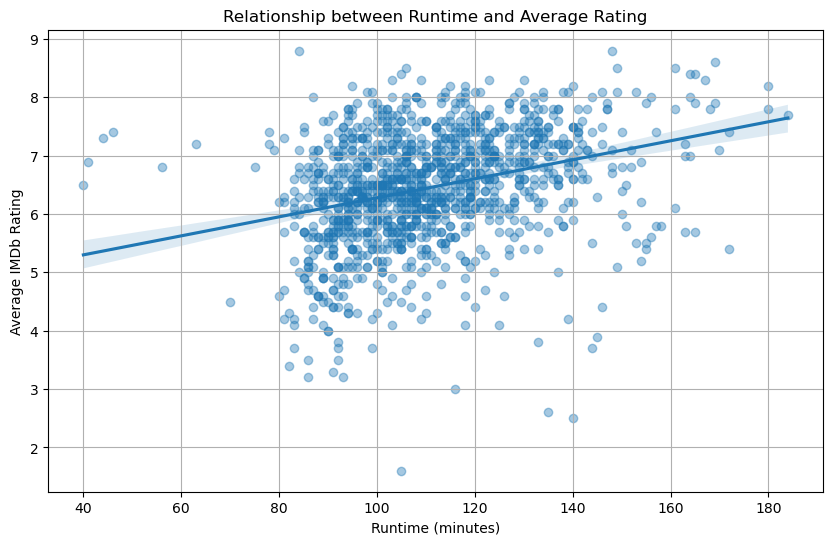

In [37]:
# A plot showing the relationship between runtime_minutes against average rating.
plt.figure(figsize=(10, 6))
sns.regplot(x='runtime_minutes', y='avg_rating', data=df_rating_runtime, scatter_kws={'alpha':0.4})
plt.title('Relationship between Runtime and Average Rating')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Average IMDb Rating')
plt.grid(True)
plt.show()

In [38]:
correlation = df_rating_runtime['runtime_minutes'].corr(df_rating_runtime['avg_rating'])
print(f"Correlation: {correlation:.3f}")

Correlation: 0.315


- The correlation of 0.315 shows a moderate positive relationship — longer movies tend to have slightly higher ratings on average, but the effect isn’t strong.
- Aim for a runtime around 110 minutes (the average), ensuring tight storytelling. If extending length, only do so with strong content, longer runtimes may slightly boost ratings but aren’t a guarantee.

Top 10 Most Profitable Movies:
                                             movie  production_budget  \
0                                           Avatar        425000000.0   
42                                         Titanic        200000000.0   
6                           Avengers: Infinity War        300000000.0   
5             Star Wars Ep. VII: The Force Awakens        306000000.0   
33                                  Jurassic World        215000000.0   
66                                       Furious 7        190000000.0   
26                                    The Avengers        225000000.0   
260  Harry Potter and the Deathly Hallows: Part II        125000000.0   
41                                   Black Panther        200000000.0   
112                 Jurassic World: Fallen Kingdom        170000000.0   

     worldwide_gross        profit  
0       2.776345e+09  2.351345e+09  
42      2.208208e+09  2.008208e+09  
6       2.048134e+09  1.748134e+09  
5       2.053311e

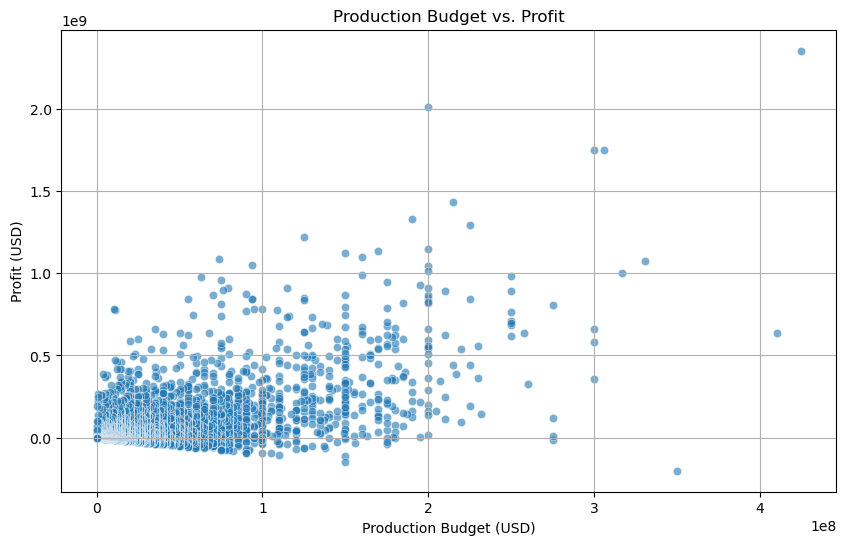

In [40]:
#looking at the production budget against Financial success(PROFIT)

# Top 10 Most Profitable Movies
budget_df['profit'] = budget_df['worldwide_gross'] - budget_df['production_budget']
top_profitable = budget_df.sort_values(by='profit', ascending=False).head(10)
print("Top 10 Most Profitable Movies:")
print(top_profitable[['movie', 'production_budget', 'worldwide_gross', 'profit']])

correlation = budget_df['production_budget'].corr(budget_df['profit'])
print(f"\nCorrelation between Production Budget and Profit: {correlation:.2f}")

# Scatter Plot - Budget vs. Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=budget_df, x='production_budget', y='profit', alpha=0.6)
plt.title('Production Budget vs. Profit')
plt.xlabel('Production Budget (USD)')
plt.ylabel('Profit (USD)')
plt.grid(True)

## **From the scater plot above:**
-While high production budgets are strongly correlated with higher profits i.e r = 0.61(production budget increases, profit tends to increase as well), but they don't guarantee success entirely since other factors such as genres, marketing, and audience reception, still play a role.marketing, and audience reception, still play a role.. Our earlier genre analysis shows that Animation, Sci-Fi and Adventure consistently appear in the top 10 most profitable movies. These genres not only attract global audiences but also justify large budgets through high returns.

### Recommendations:

### **1. Genre Strategy Recommendation**  
**Based on Genre Total Gross Visualization**  
> *"Focus production on **Animation-Sci-Fi hybrids**, allocating 60% of development budget to these genres. Use Adventure elements (quests/challenges) to broaden appeal, as these combinations dominate the top 5 highest-grossing genres in our analysisting*  

---

### **2. Runtime Optimization Recommendation**  
> *"Aim for a runtime around 105 to 110 minutes, aligning with the average and the range where most high-rated movies fall. This allows for tight, focused storytelling while maximizing the likelihood of favorable audience ratings. Given our genre insights, films within this runtime bracket tend to perform better both in volume and average rating.*

---

### **3. Budget vs. Financial Success (Profitability)**  
> *"Focus investment on high-budget productions within proven blockbuster genres like Action, Adventure, and Sci-Fi, where both profitability and audience reception tend to align. Prioritize compelling storytelling with broad appeal to maximize both ratings and revenue."*
---